In [2]:
from tensorflow.keras.datasets import cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1592s 9us/step
(50000, 32, 32, 3) (50000, 1)
(10000, 32, 32, 3) (10000, 1)


In [3]:
import numpy as np
from sklearn.model_selection import train_test_split

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

x_tr, x_val, y_tr, y_val = train_test_split(
    x_train_norm, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print("Train:", x_tr.shape, y_tr.shape)
print("Val:", x_val.shape, y_val.shape)
print("Test:", x_test_norm.shape, y_test.shape)

Train: (40000, 32, 32, 3) (40000, 1)
Val: (10000, 32, 32, 3) (10000, 1)
Test: (10000, 32, 32, 3) (10000, 1)


In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint

baseline_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint_baseline = ModelCheckpoint(
    'baseline_best.keras', save_best_only=True, monitor='val_accuracy'
)

history_baseline = baseline_model.fit(
    x_tr, y_tr,
    validation_data=(x_val, y_val),
    epochs=15,
    callbacks=[checkpoint_baseline]
)

test_loss_base, test_acc_base = baseline_model.evaluate(x_test_norm, y_test)
print(f"Baseline Test Accuracy: {test_acc_base:.4f}")

Epoch 1/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.3950 - loss: 1.6667 - val_accuracy: 0.5340 - val_loss: 1.3242
Epoch 2/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5280 - loss: 1.3147 - val_accuracy: 0.6122 - val_loss: 1.1203
Epoch 3/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5785 - loss: 1.1900 - val_accuracy: 0.6217 - val_loss: 1.0644
Epoch 4/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6061 - loss: 1.1031 - val_accuracy: 0.6393 - val_loss: 1.0342
Epoch 5/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6346 - loss: 1.0371 - val_accuracy: 0.6663 - val_loss: 0.9400
Epoch 6/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6537 - loss: 0.9881 - val_accuracy: 0.6878 - val_loss: 0.9017
Epoch 7/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6727 - loss: 0.9301 - val_accuracy: 0.6869 - val_loss: 0.9025
Epoch 8/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6856 - loss: 0.8869 -

In [5]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

improved_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    data_augmentation,
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

improved_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint_improved = ModelCheckpoint(
    'improved_best.keras', save_best_only=True, monitor='val_accuracy'
)

history_improved = improved_model.fit(
    x_tr, y_tr,
    validation_data=(x_val, y_val),
    epochs=30,
    callbacks=[checkpoint_improved]₩₩
)

test_loss_imp, test_acc_imp = improved_model.evaluate(x_test_norm, y_test)
print(f"Improved Test Accuracy: {test_acc_imp:.4f}")

Epoch 1/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.3742 - loss: 1.7130 - val_accuracy: 0.2869 - val_loss: 2.5780
Epoch 2/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.4894 - loss: 1.4142 - val_accuracy: 0.5540 - val_loss: 1.2629
Epoch 3/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.5335 - loss: 1.2987 - val_accuracy: 0.5836 - val_loss: 1.1667
Epoch 4/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.5633 - loss: 1.2250 - val_accuracy: 0.5484 - val_loss: 1.2782
Epoch 5/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.5874 - loss: 1.1692 - val_accuracy: 0.6233 - val_loss: 1.0976
Epoch 6/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.6065 - loss: 1.1278 - val_accuracy: 0.5993 - val_loss: 1.1258
Epoch 7/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.6194 - loss: 1.0898 - val_accuracy: 0.6607 - val_loss: 0.9494
Epoch 8/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.6308 -

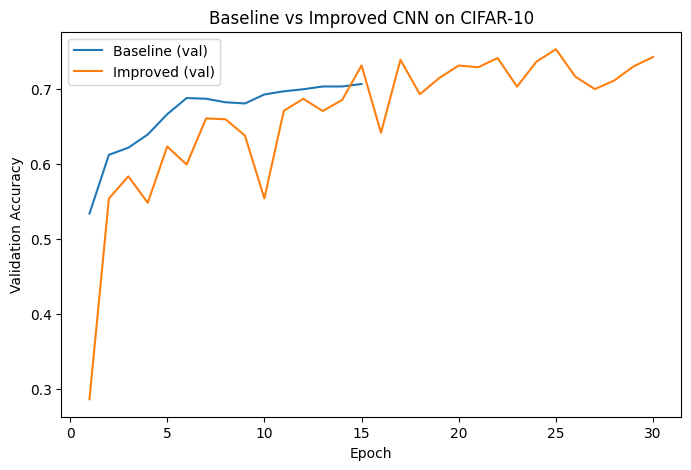

In [6]:
import matplotlib.pyplot as plt

acc_base = history_baseline.history['val_accuracy']
acc_imp = history_improved.history['val_accuracy']

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(acc_base)+1), acc_base, label='Baseline (val)')
plt.plot(range(1, len(acc_imp)+1), acc_imp, label='Improved (val)')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Baseline vs Improved CNN on CIFAR-10')
plt.legend()
plt.show()